In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
df = pd.read_csv("airbnb_data.csv")

In [3]:
numeric_cols = ['bathrooms', 'review_scores_rating', 'bedrooms', 'beds']
for col in numeric_cols:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value)

In [5]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)][col]
    
    percent_outliers = (len(outliers) / len(df[col])) * 100
    
    print(f"{col:<25} : {percent_outliers:6.2f}% outliers")

id                        :   0.00% outliers
log_price                 :   2.07% outliers
accommodates              :   4.86% outliers
bathrooms                 :  21.34% outliers
latitude                  :   0.00% outliers
longitude                 :   0.00% outliers
number_of_reviews         :  11.07% outliers
review_scores_rating      :   6.24% outliers
bedrooms                  :  32.70% outliers
beds                      :   7.67% outliers


col unique values: [ 1.  3.  2.  0.  4.  5.  6.  7.  8.  9. 10.]


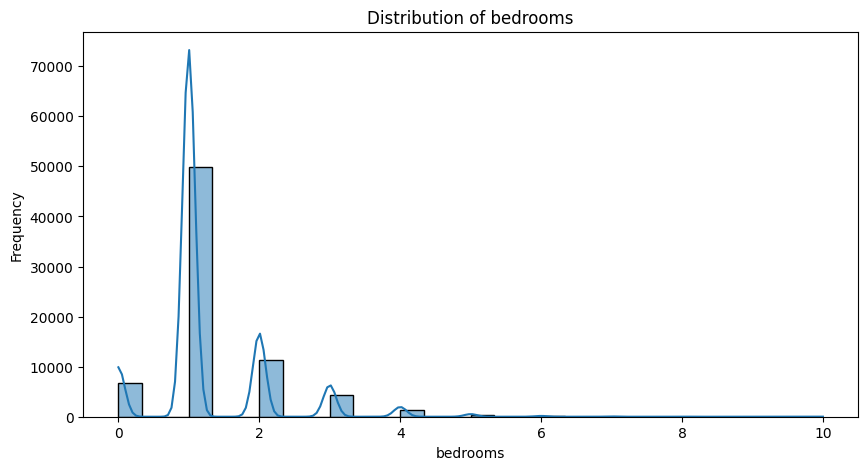

In [6]:
print("col unique values:", df['bedrooms'].unique())
plt.figure(figsize=(10,5))
sns.histplot(df['bedrooms'], kde=True, bins=30)
plt.title("Distribution of bedrooms")
plt.xlabel('bedrooms')
plt.ylabel("Frequency")
plt.show()

## Bedrooms column is right-skewed and most values (0–2) are normal and very few values lies around at 6-10
## We cap only the top 1% extreme values using the 99th percentile only for tail part.
# That Result
# - Keeps 99% data same
# - Removes extreme highs
# - Range ~0–4 → better for linear regression

In [13]:
upper = df['bedrooms'].quantile(0.99)
print("99th Percentile (Upper Limit):", upper)

df['bedrooms_capped'] = np.where(df['bedrooms'] > upper, upper, df['bedrooms'])

99th Percentile (Upper Limit): 4.0


col unique values: [1. 3. 2. 0. 4.]


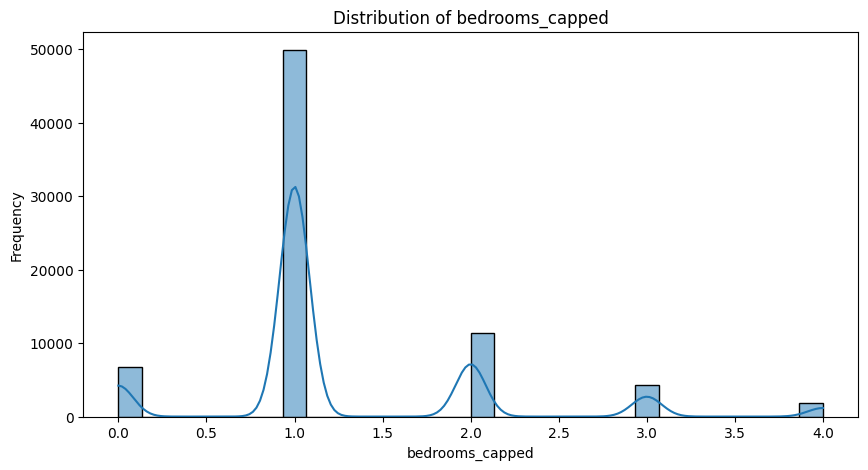

In [14]:
print("col unique values:", df['bedrooms_capped'].unique())
plt.figure(figsize=(10,5))
sns.histplot(df['bedrooms_capped'], kde=True, bins=30)
plt.title("Distribution of bedrooms_capped")
plt.xlabel('bedrooms_capped')
plt.ylabel("Frequency")
plt.show()